In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

In [51]:

data = pd.read_csv('data (1).csv')




In [52]:
print(data.isnull().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [53]:
data.drop(['Unnamed: 32', 'id'], axis=1, inplace=True , errors='ignore')
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [54]:
y = data['diagnosis'].values
x_data = data.drop(['diagnosis'], axis=1)

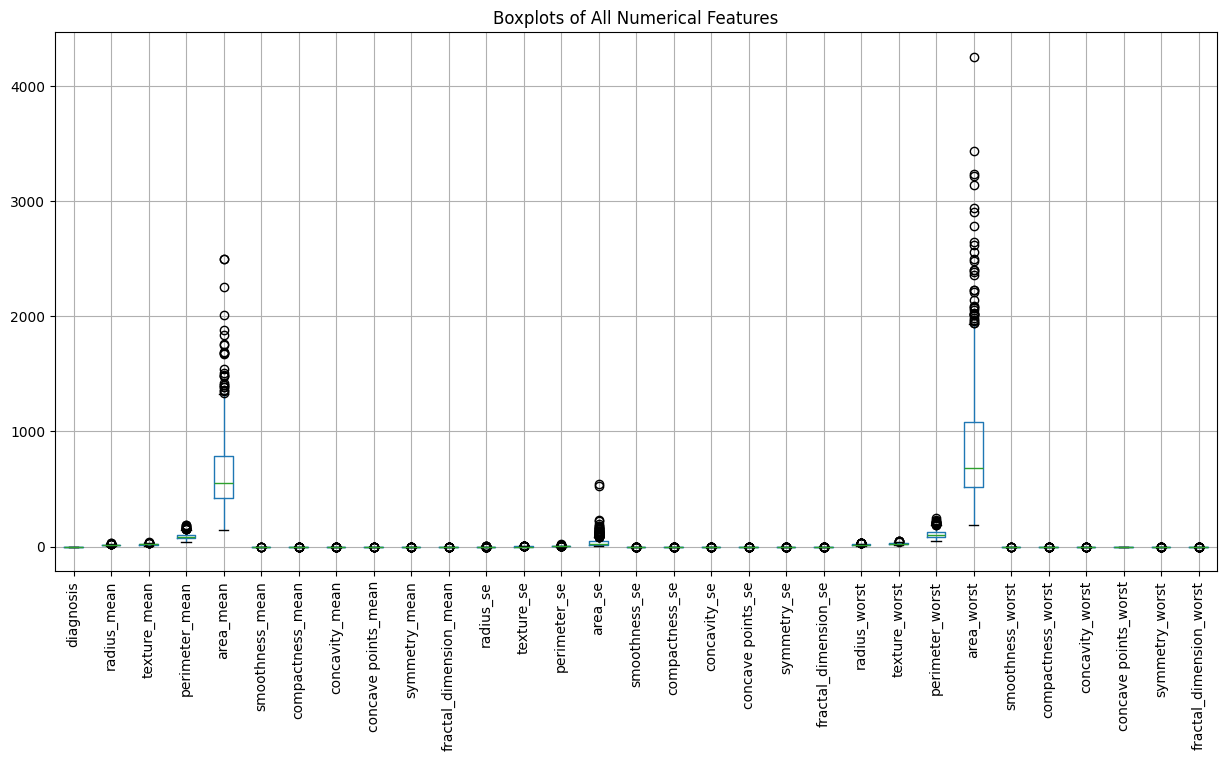

In [55]:
plt.figure(figsize=(15, 7))
data.boxplot()
plt.title("Boxplots of All Numerical Features")
plt.xticks(rotation=90)
plt.show()

Columns chosen for selective standardization: ['area_mean', 'perimeter_mean', 'area_worst', 'perimeter_worst']

 Standardization applied ONLY to selected outlier-heavy columns.



C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


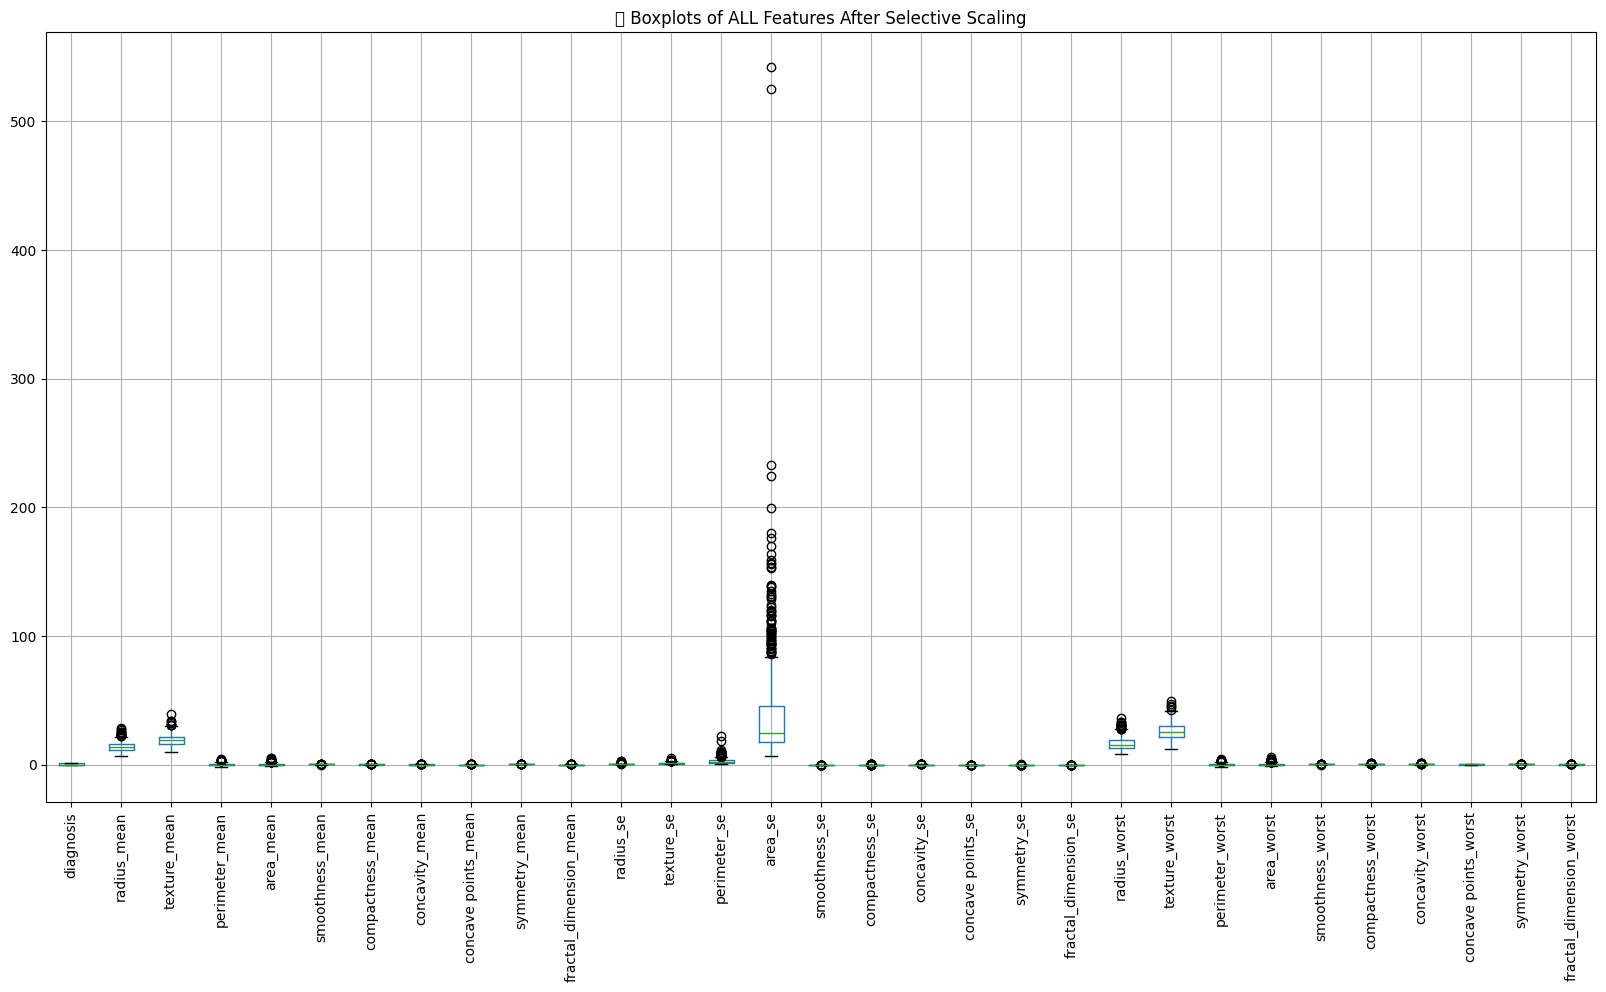

In [ ]:
outlier_columns = [
    'area_mean',
    'perimeter_mean',
    'area_worst',
    'perimeter_worst'
]

print("Columns chosen for selective standardization:", outlier_columns)


scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[outlier_columns] = scaler.fit_transform(data[outlier_columns])
print("\n Standardization applied ONLY to selected outlier-heavy columns.\n")


plt.figure(figsize=(20, 10))
data_scaled.boxplot()
plt.title(" Boxplots of ALL Features After Selective Scaling")
plt.xticks(rotation=90)
plt.show()

In [57]:
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.678668,0.566490,0.526948,0.296055,0.571462,0.690358,0.336364,0.132056,...,0.623266,0.383262,0.576174,0.452664,0.461137,0.178527,0.328035,0.761512,0.097575,0.105667
565,0.622320,0.626987,0.604036,0.474019,0.407782,0.257714,0.337395,0.486630,0.349495,0.113100,...,0.560655,0.699094,0.520892,0.379915,0.300007,0.159997,0.256789,0.559450,0.198502,0.074315
566,0.455251,0.621238,0.445788,0.303118,0.288165,0.254340,0.216753,0.263519,0.267677,0.137321,...,0.393099,0.589019,0.379949,0.230731,0.282177,0.273705,0.271805,0.487285,0.128721,0.151909
567,0.644564,0.663510,0.665538,0.475716,0.588336,0.790197,0.823336,0.755467,0.675253,0.425442,...,0.633582,0.730277,0.668310,0.402035,0.619626,0.815758,0.749760,0.910653,0.497142,0.452315


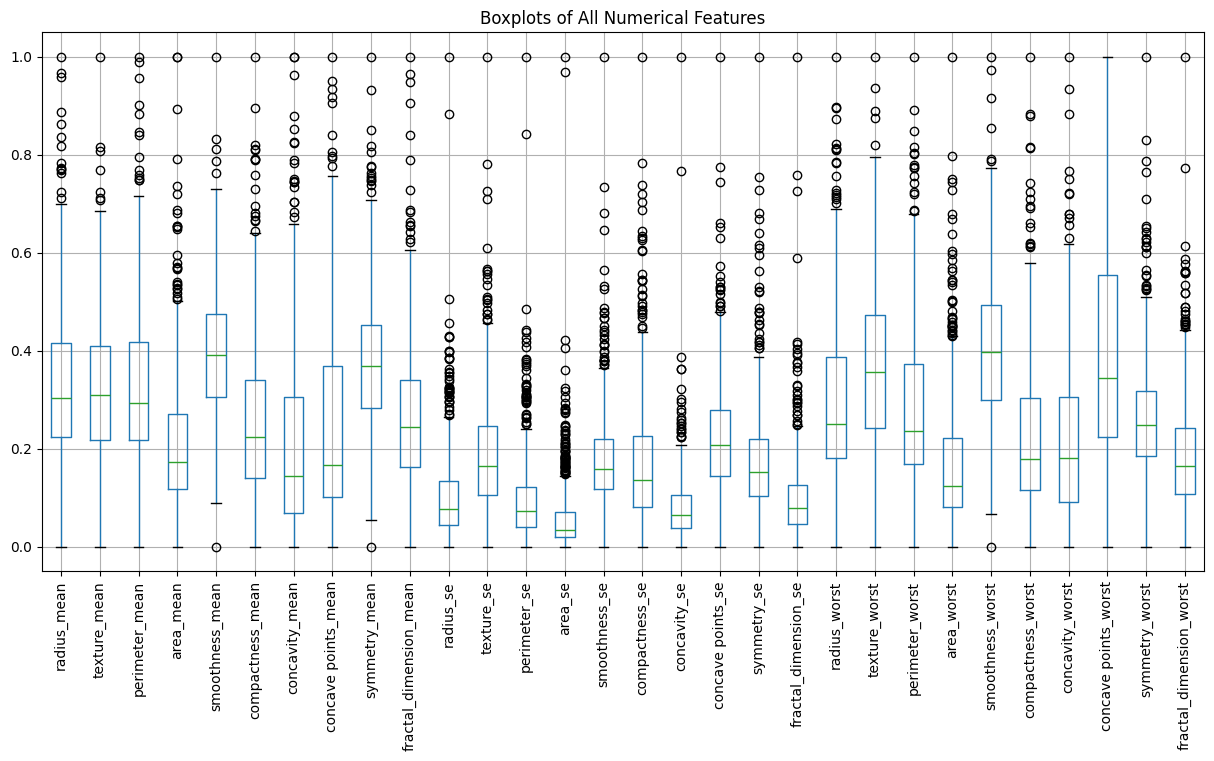

In [58]:
plt.figure(figsize=(15, 7))

x.boxplot(rot=90)
plt.title("Boxplots of All Numerical Features")
plt.show()

In [83]:
from sklearn.model_selection import train_test_split
import numpy as np


train_data, temp_data = train_test_split(
    data_scaled,
    test_size=0.7,          
    random_state=42,
    stratify=data_scaled['diagnosis']
)



test1_data, test2_data = train_test_split(
    temp_data,
    test_size=0.5,           
    random_state=42,
    stratify=temp_data['diagnosis']
)


print(f"Train: {train_data.shape}, Test1: {test1_data.shape}, Test2: {test2_data.shape}")



X_train = train_data.drop('diagnosis', axis=1).values
y_train = train_data['diagnosis'].values.reshape(-1,1)

X_test1 = test1_data.drop('diagnosis', axis=1).values
y_test1 = test1_data['diagnosis'].values.reshape(-1,1)

X_test2 = test2_data.drop('diagnosis', axis=1).values
y_test2 = test2_data['diagnosis'].values.reshape(-1,1)


X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test1_bias = np.c_[np.ones((X_test1.shape[0], 1)), X_test1]
X_test2_bias = np.c_[np.ones((X_test2.shape[0], 1)), X_test2]


Train: (170, 31), Test1: (199, 31), Test2: (200, 31)


In [84]:


svm_linear = SVC(kernel='linear', C=10, random_state=42)
svm_linear.fit(X_train, y_train.ravel())  

print(" Linear SVM model trained successfully!")


 Linear SVM model trained successfully!


In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    print(f"\n {dataset_name} Evaluation Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.show()



📘 Training Data Evaluation Metrics:
Accuracy : 0.9765
Precision: 1.0000
Recall   : 0.9365
F1-Score : 0.9672


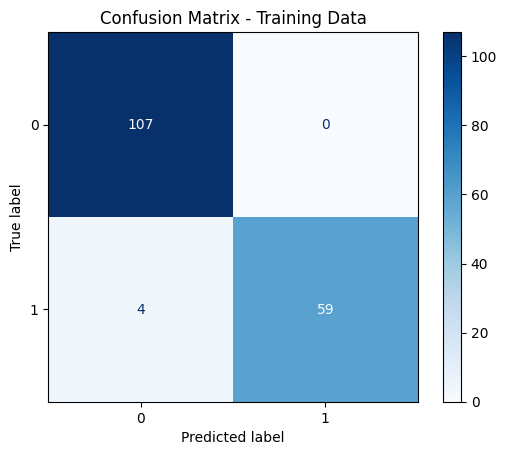

In [86]:

evaluate_model(svm_linear, X_train, y_train, "Training Data")




📘 Test1 Data Evaluation Metrics:
Accuracy : 0.9749
Precision: 0.9859
Recall   : 0.9459
F1-Score : 0.9655


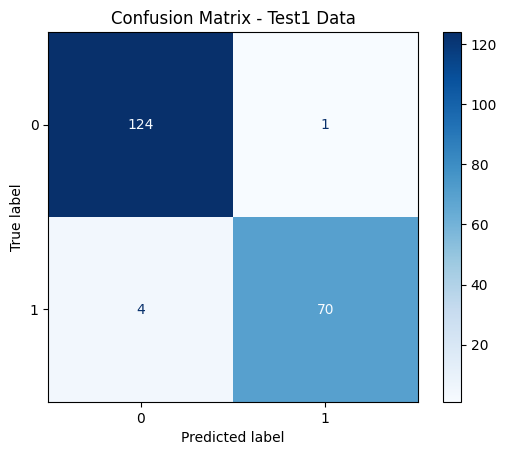

In [87]:

evaluate_model(svm_linear, X_test1, y_test1, "Test1 Data")




📘 Test2 Data Evaluation Metrics:
Accuracy : 0.9500
Precision: 0.9710
Recall   : 0.8933
F1-Score : 0.9306


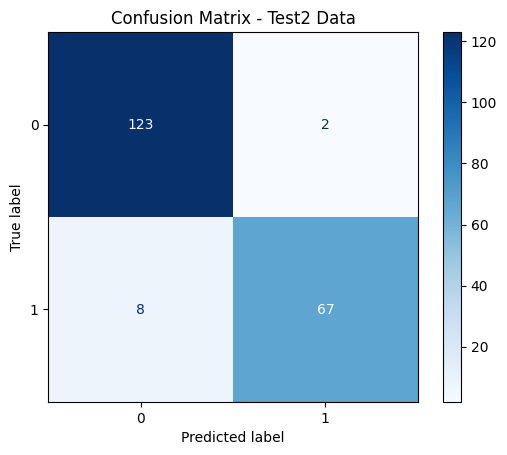

In [88]:

evaluate_model(svm_linear, X_test2, y_test2, "Test2 Data")



📘 Test1 Data (Polynomial Kernel) Evaluation Metrics:
Accuracy : 0.9146
Precision: 1.0000
Recall   : 0.7703
F1-Score : 0.8702


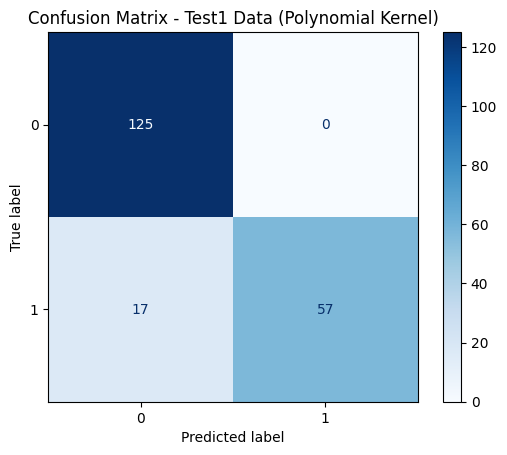

In [89]:

svm_poly = SVC(kernel='poly', degree=3, C=10, random_state=42)
svm_poly.fit(X_train, y_train.ravel())
evaluate_model(svm_poly, X_test1, y_test1, "Test1 Data (Polynomial Kernel)")





📘 Test1 Data (RBF Kernel) Evaluation Metrics:
Accuracy : 0.9045
Precision: 0.9825
Recall   : 0.7568
F1-Score : 0.8550


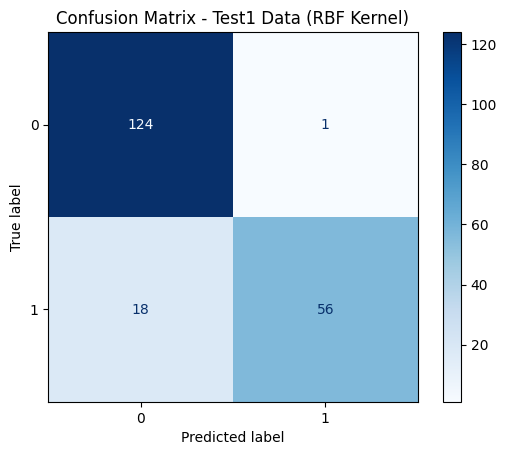

In [90]:

svm_rbf = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
svm_rbf.fit(X_train, y_train.ravel())
evaluate_model(svm_rbf, X_test1, y_test1, "Test1 Data (RBF Kernel)")

In [91]:

from sklearn.model_selection import GridSearchCV


param_grid = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],  
    'degree': [2, 3, 4]  
}


svm = SVC(random_state=42)


grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,  
    verbose=2
)


grid_search.fit(X_train, y_train.ravel())


print("\n🔍 Best Parameters Found:")
print(grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits

🔍 Best Parameters Found:
{'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy: 0.9412



 Evaluating Tuned SVM Model on All Datasets...

📘 Training Data (Tuned Model) Evaluation Metrics:
Accuracy : 0.9765
Precision: 1.0000
Recall   : 0.9365
F1-Score : 0.9672


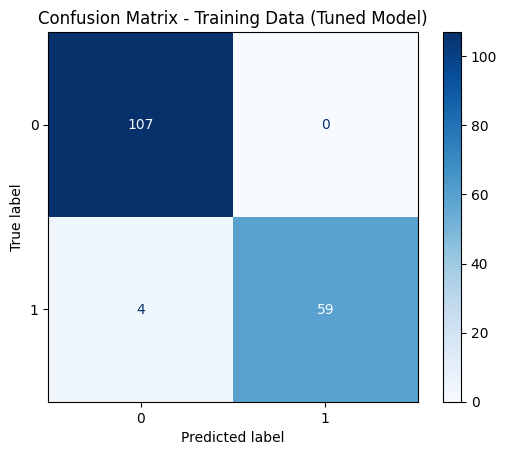

In [92]:

best_svm = grid_search.best_estimator_

print("\n Evaluating Tuned SVM Model on All Datasets...")
evaluate_model(best_svm, X_train, y_train, "Training Data (Tuned Model)")



📘 Test1 Data (Tuned Model) Evaluation Metrics:
Accuracy : 0.9749
Precision: 0.9859
Recall   : 0.9459
F1-Score : 0.9655


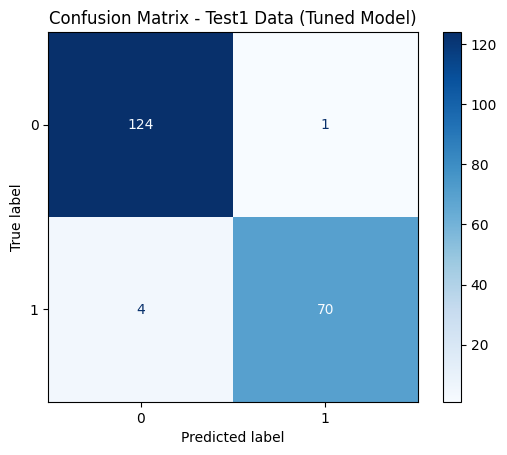

In [93]:
evaluate_model(best_svm, X_test1, y_test1, "Test1 Data (Tuned Model)")




📘 Test2 Data (Tuned Model) Evaluation Metrics:
Accuracy : 0.9500
Precision: 0.9710
Recall   : 0.8933
F1-Score : 0.9306


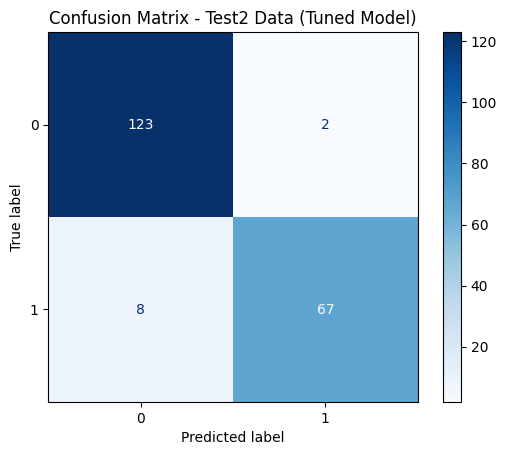

In [94]:

evaluate_model(best_svm, X_test2, y_test2, "Test2 Data (Tuned Model)")


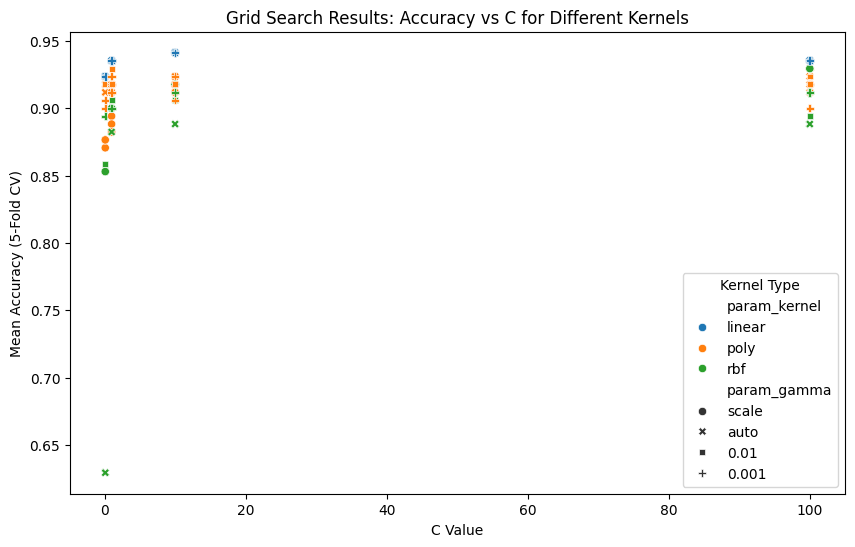

In [95]:

results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results, x='param_C', y='mean_test_score', hue='param_kernel', style='param_gamma')
plt.title("Grid Search Results: Accuracy vs C for Different Kernels")
plt.xlabel("C Value")
plt.ylabel("Mean Accuracy (5-Fold CV)")
plt.legend(title="Kernel Type")
plt.show()



📘 Training Data (Recall-Oriented Model) Evaluation Metrics:
Accuracy : 0.9706
Precision: 0.9531
Recall   : 0.9683
F1-Score : 0.9606


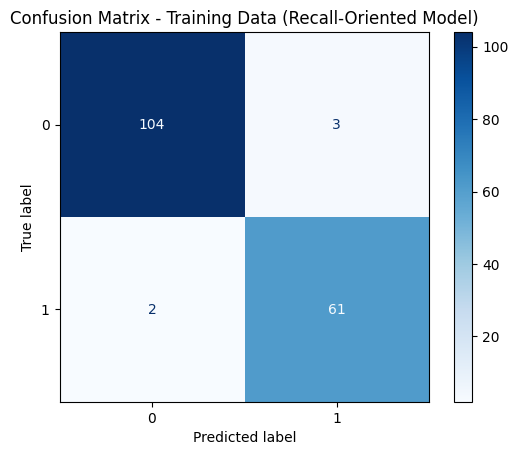


📘 Test1 Data (Recall-Oriented Model) Evaluation Metrics:
Accuracy : 0.9447
Precision: 0.9315
Recall   : 0.9189
F1-Score : 0.9252


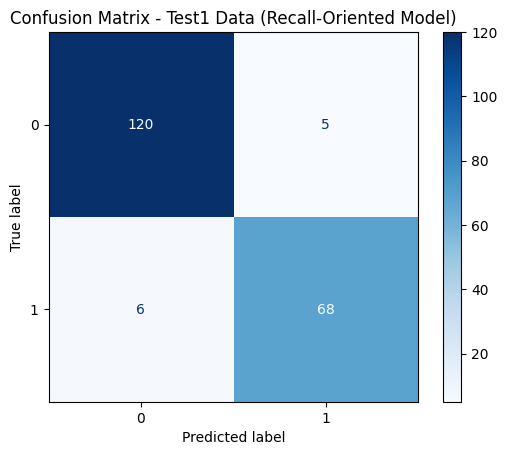


📘 Test2 Data (Recall-Oriented Model) Evaluation Metrics:
Accuracy : 0.9300
Precision: 0.9552
Recall   : 0.8533
F1-Score : 0.9014


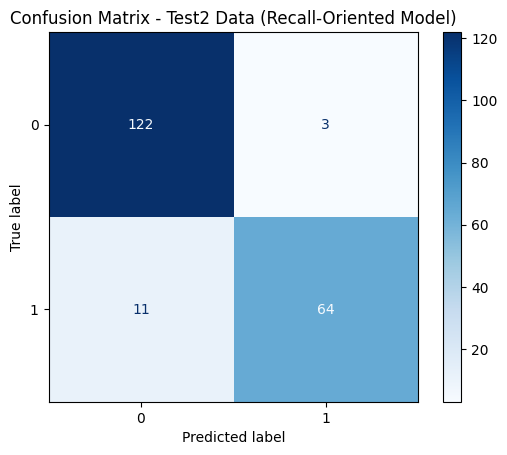

In [96]:

from sklearn.svm import SVC


svm_recall = SVC(kernel='rbf', C=100, gamma=0.001, class_weight='balanced', random_state=42)
svm_recall.fit(X_train, y_train.ravel())
 
evaluate_model(svm_recall, X_train, y_train, "Training Data (Recall-Oriented Model)")
evaluate_model(svm_recall, X_test1, y_test1, "Test1 Data (Recall-Oriented Model)")
evaluate_model(svm_recall, X_test2, y_test2, "Test2 Data (Recall-Oriented Model)")
